In [ ]:
!pip uninstall tensorflow

In [5]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os

In [6]:
Image_Width=128
Image_Height=128
Image_Size=(Image_Width,Image_Height)
Image_Channels=3

In [7]:
filenames=os.listdir("./train")

categories=[]
for f_name in filenames:
    category=f_name.split('.')[0] # 会把文件名按照点号切开，变成['dog','15','jpg']
    if category=='dog':
        categories.append(1)
    else:
        categories.append(0)

df=pd.DataFrame({
    'filename':filenames,
    'category':categories
})

In [8]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,\
     Dropout,Flatten,Dense,Activation,\
     BatchNormalization

model=Sequential()

## 第一部分：特征提取层（三层卷积块）

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(Image_Width,Image_Height,Image_Channels))) 
# 32：过滤器的数量，第一层较少，用于提取简单的边缘、线条； (3,3)过滤器的大小（卷积核）3x3是工业标准，既能捕捉局部特征，计算量又适中
model.add(BatchNormalization()) # （批标准化）在每一层之后将数据重新拉回到标准正态分布，能够让模型训练得很快、更稳定，防止梯度消失
model.add(MaxPooling2D(pool_size=(2,2))) # （最大池化）压缩图片尺寸，把2x2区域内最大的像素值留下来
model.add(Dropout(0.25)) # （随机失活） 每次训练时随机关闭25%的神经元，方法过拟合，强迫模型不要死记硬背某几张图的特征，而是学习更通用的规律

# 第二次卷积用了64个过滤器，第三层用了128个
# 原理：层数越深，过滤器越多，模型能从简单的线条特征进化到识别复杂的形状（如眼睛、耳朵、胡须）
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

## 第二部分：分类判别层（全连接层）

model.add(Flatten()) # （扁平化）把三维的特征图（长，宽、通道）摊平变成一维的长向量； 为了能提取到的特征输入到最后的分类器(Dense层)中
model.add(Dense(512,activation='relu')) # 拥有512个神经元的大型大脑，他负责根据前面提取到的所有特征进行逻辑推理
model.add(BatchNormalization())
model.add(Dropout(0.5)) # 设置了更高的失活率（50%）,因为全连接层参数极多，最容易产生死记硬背（过拟合）
model.add(Dense(2,activation='softmax')) # （输出层） 2：因为要分两类（猫、狗）softmax:将输出转换为概率

# 模型编译

model.compile(loss='categorical_crossentropy', # 损失函数，多分类任务的标准配置，衡量的是模型预测的概率分布与真实标签之间的差距
              optimizer='rmsprop', # （优化器） RMSprop是深度学习中非常经典且高效的优化器，尤其擅长处理卷积神经网络，它会自动调整学习率，让模型更平稳地找到最优解
              metrics=['accuracy']) # 评估指标 训练过程中我们要看的指标——准确率

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │      12,845,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,942,786 (49.37 MB)

 Trainable params: 12,941,314 (49.37 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [15]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
earlystop = EarlyStopping(patience = 10) # earlystop（早停机制） 防止浪费时间和过拟合，如果模型连续10轮都没有进步，会强制提前结束训练
learning_rate_reduction = ReduceLROnPlateau(monitor = 'val_accuracy',patience = 2,verbose = 1,factor = 0.5,min_lr = 0.00001)
# ReduceLROnPlateau（学习率衰减，当模型遇到瓶颈时，让步子迈得小一些）
# monitor = 'val_acc' 监视的指标是验证集准确率
# patience = 2 如果连续2轮准确率没有提升，就是采取相应的行动
# verbose = 1 当降低学习率时，会在屏幕打出一行字告诉你，步子收小了
# factor = 0.5 行动方案：把学习率减半
# min_lr = 0.00001 学习率最小不能小于这个数，否则模型就彻底不动了
callbacks = [earlystop,learning_rate_reduction]

In [16]:
df["category"] = df["category"].replace({0:'cat',1:'dog'})
train_df,validate_df = train_test_split(df,test_size=0.20,random_state=42)

# 重置索引
train_df = train_df.reset_index(drop=True) 
validate_df = validate_df.reset_index(drop=True)

# 统计数量与设置批量大小
total_train=train_df.shape[0] # 统计训练集一共有多少张图
total_validate=validate_df.shape[0] # 统计验证集一共有多少张图
batch_size=15 # 设置“每批次”处理的数量

In [36]:
## 训练与验证数据生成器
# 数据增强
train_datagen = ImageDataGenerator(rotation_range=15, # 随机旋转图片，最大15度
                                rescale=1./255, # 归一化，把像素值从[0-255]缩放到[0-1]，神经网络非常喜欢0到1之间的小数，这能让训练更加稳定
                                shear_range=0.1, # 随机错切变换（把图片像平行四边形一样拉伸）
                                zoom_range=0.2, # 随机放大或缩小（最大20%）
                                horizontal_flip=True, # 水平翻转
                                #水平或垂直平移图片
                                width_shift_range=0.1, 
                                height_shift_range=0.1
                                )

# 训练集生成器（类似于一个传动带，一遍看着train_df表格里的名字，一遍去硬盘里搬运对应的图片，进行选装、缩放处理，然后打包成一包15张送进模型）
train_generator = train_datagen.flow_from_dataframe(train_df, # 包含文件名和标签的表格
                                                 "./train/",x_col='filename',y_col='category',
                                                 target_size=Image_Size, # 统一缩放到你设定的尺寸
                                                 class_mode='categorical', # 分类模式（对应之前的cat/dog字符串）
                                                 batch_size=batch_size)

# 验证集生成器
validation_datagen = ImageDataGenerator(rescale=1./255) # 验证集只做归一化，不做任何其他增强
validation_generator = validation_datagen.flow_from_dataframe(
    validate_df, 
    "./train/", 
    x_col='filename',
    y_col='category',
    target_size=Image_Size,
    class_mode='categorical',
    batch_size=batch_size
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = train_datagen.flow_from_dataframe(test_df,
                                                 "./test1/",
                                                 x_col='filename',
                                                 y_col=None,
                                                 target_size=Image_Size,
                                                 class_mode=None,
                                                 batch_size=batch_size,
                                                 shuffle=False)

Found 801 validated image filenames belonging to 2 classes.
Found 201 validated image filenames belonging to 2 classes.
Found 245 validated image filenames.


In [37]:
epochs=10
history = model.fit(
    train_generator, 
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=total_validate//batch_size,
    steps_per_epoch=total_train//batch_size,
    callbacks=callbacks
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 302ms/step - accuracy: 0.6590 - loss: 0.7033 - val_accuracy: 0.4872 - val_loss: 1.4858 - learning_rate: 6.2500e-05
Epoch 2/10
 1/53 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.5333 - loss: 0.7763

F:\Anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5333 - loss: 0.7763 - val_accuracy: 0.4923 - val_loss: 1.4462 - learning_rate: 6.2500e-05
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 15s 283ms/step - accuracy: 0.6730 - loss: 0.6865 - val_accuracy: 0.5179 - val_loss: 1.2246 - learning_rate: 3.1250e-05
Epoch 4/10
 1/53 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.7333 - loss: 0.5914
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7333 - loss: 0.5914 - val_accuracy: 0.5026 - val_loss: 1.2282 - learning_rate: 3.1250e-05
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 310ms/step - accuracy: 0.6972 - loss: 0.6467 - val_accuracy: 0.5436 - val_loss: 1.0505 - learning_rate: 1.5625e-05
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5333 - loss: 1.1774 - val_accuracy: 0.5538 - val_loss: 1.0432 - learning_rate: 1.5625e-05
Epo

In [38]:
model.save("model1_catsVSdogs_10epoch.h5")

In [39]:
test_filenames = os.listdir("./test1")
test_df = pd.DataFrame({
    'filename': test_filenames
})
nb_samples = test_df.shape[0]

In [40]:
nb_samples # 表示测试集的数量

245

In [41]:
print(test_df.head())

  filename
0    1.jpg
1   10.jpg
2  100.jpg
3  101.jpg
4  102.jpg


In [42]:
import os
path = "./test1/"
if os.path.exists(path):
    print(f"文件夹存在，里面有 {len(os.listdir(path))} 个文件")
else:
    print("错误：文件夹路径不存在！请检查路径是否正确。")

文件夹存在，里面有 245 个文件


In [44]:
predict = model.predict(test_generator) # 进行分类预测

17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 381ms/step


In [45]:
# 将标签转换为类别
test_df['category'] = np.argmax(predict, axis=-1)

label_map = dict((v,k) for k,v in train_generator.class_indices.items())
test_df['category'] = test_df['category'].replace(label_map)

test_df['category'] = test_df['category'].replace({ 'dog': 1, 'cat': 0 })

# 上述代码的含义：
# 假设模型预测某张图的概率是[0.05,0.95]
# 1.np.argmax:得到索引1
# 2.label_map：查询子带你，发现1对应的是dog
# 第一次replace：表格里填入dog
# 第二次replace: 按照最终要求，把dog变成数字1

C:\Users\jkcui\AppData\Local\Temp\ipykernel_26716\3184397957.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['category'] = test_df['category'].replace({ 'dog': 1, 'cat': 0 })


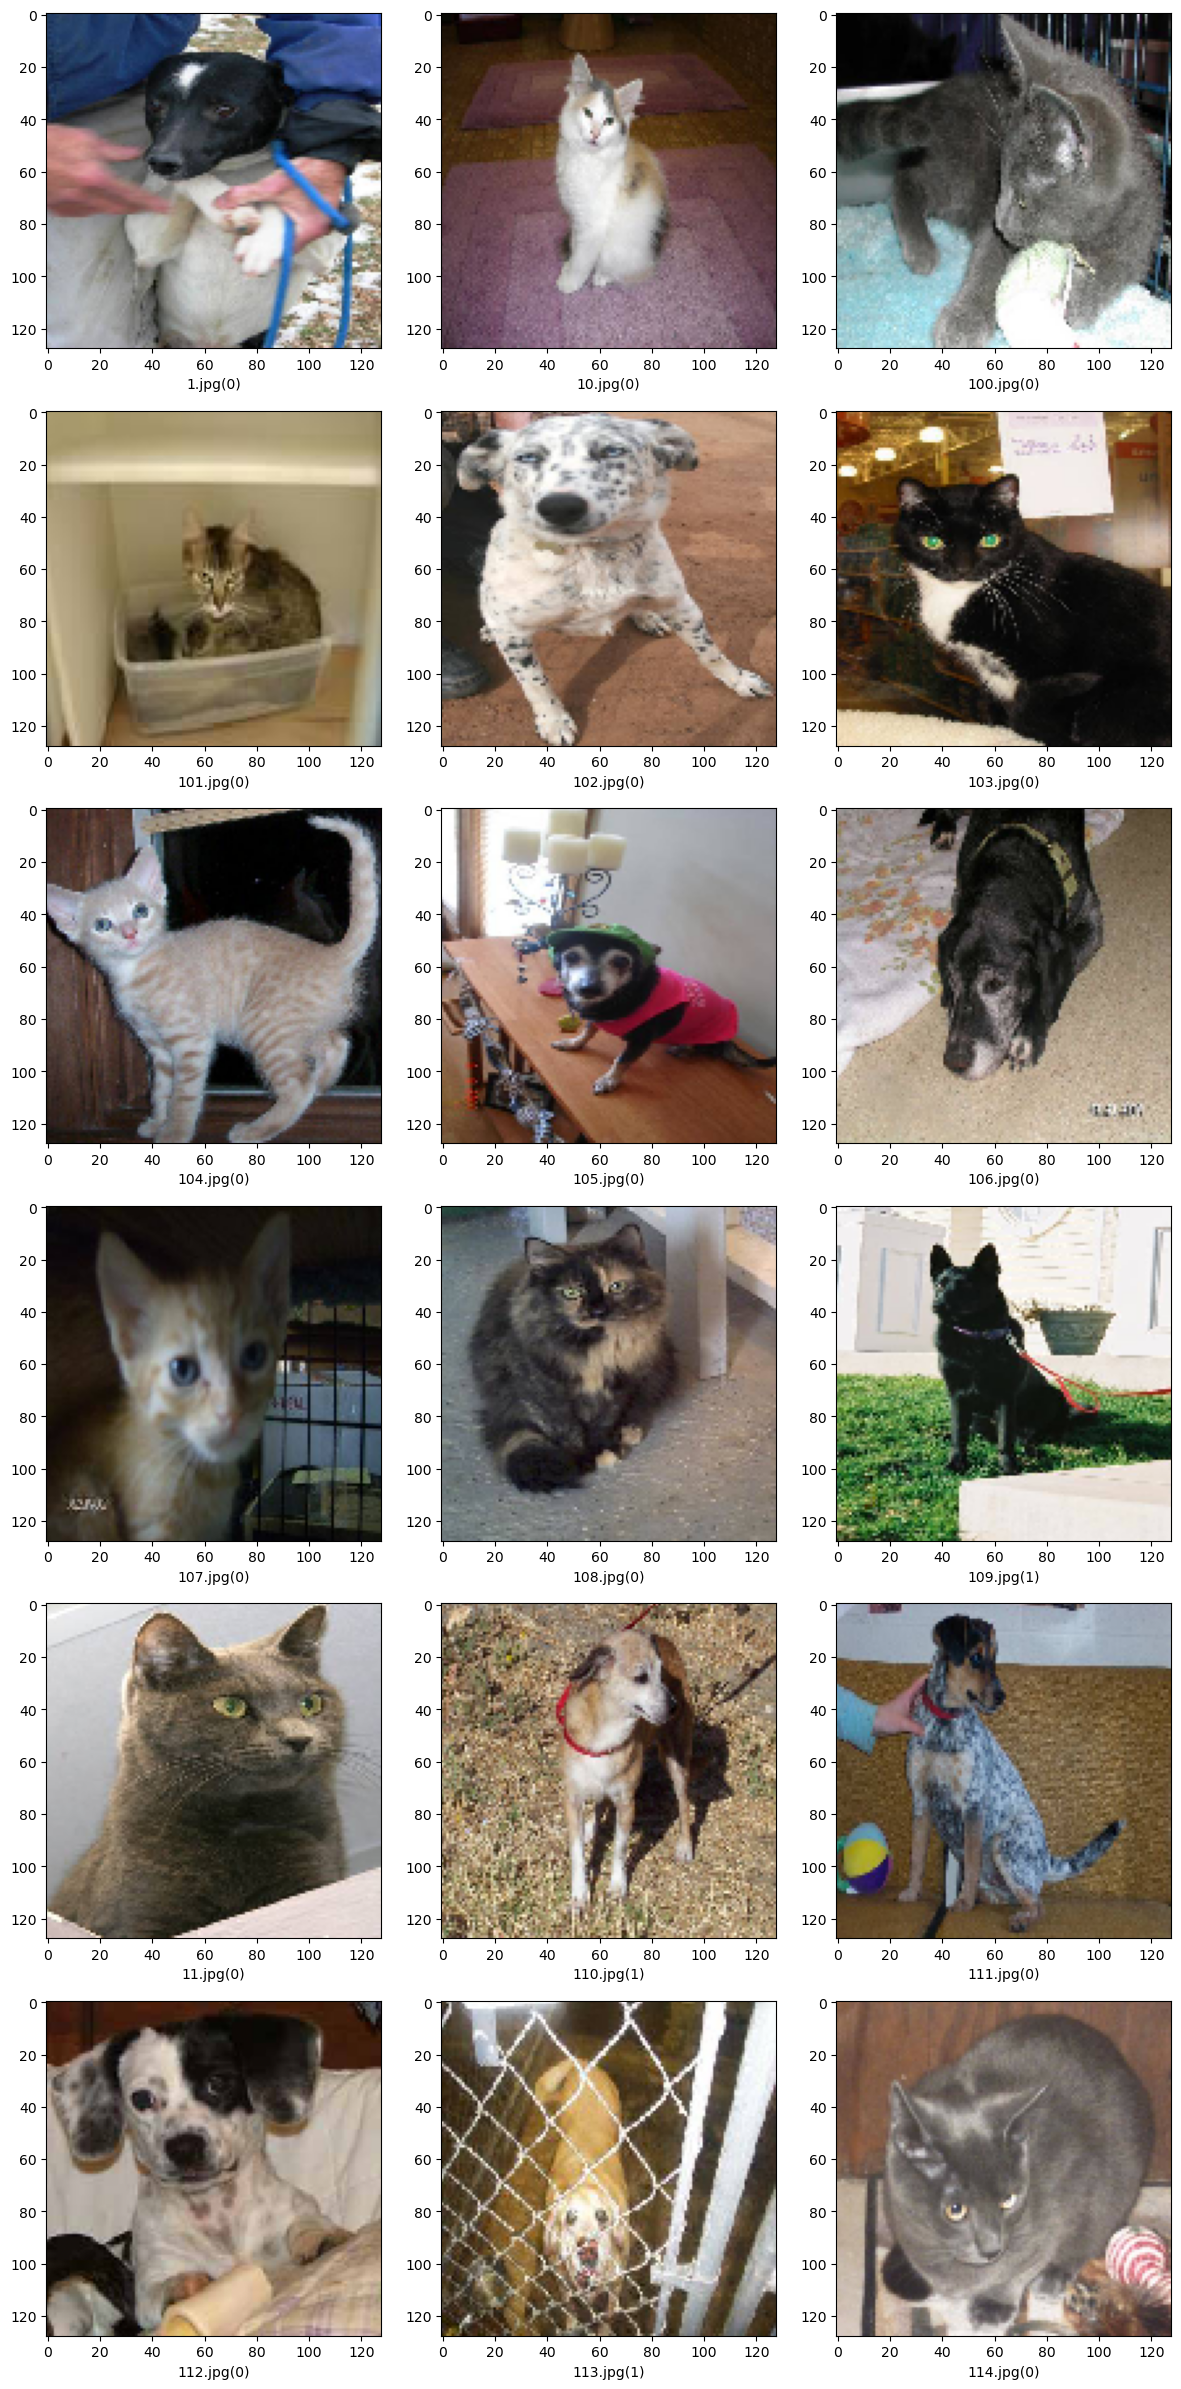

In [47]:
# 可视化预测结果
sample_test = test_df.head(18)
sample_test.head()
plt.figure(figsize=(12, 24))
for index, row in sample_test.iterrows():
    filename = row['filename']
    category = row['category']
    img = load_img("./test1/"+filename, target_size=Image_Size)
    plt.subplot(6, 3, index+1)
    plt.imshow(img)
    plt.xlabel(filename + '(' + "{}".format(category) + ')' )
plt.tight_layout()
plt.show()

In [57]:
# 1. 定义分类结果字典
results = {0: 'cat', 1: 'dog'}

from PIL import Image
import numpy as np

# 2. 读取并处理图片
# 请确保 Image_Width 和 Image_Height 是你之前定义的数字（如 128）
im = Image.open(r"E:\jupyter_projects\Data_Flair\测试集\110.jpg")
im = im.resize((Image_Width, Image_Height)) # 缩放到模型要求的尺寸
im = np.array(im)                           # 转换为数组
im = im / 255.0                             # 归一化（0-1之间）
im = np.expand_dims(im, axis=0)             # 重点：增加“批次”维度，变成 (1, 128, 128, 3)

# 3. 核心修改：用 predict 代替 predict_classes
# 先预测概率，再找概率最大的索引
pred_probabilities = model.predict(im)
pred = np.argmax(pred_probabilities, axis=-1)[0]

# 4. 打印最终结果
print(f"预测数字: {pred}, 识别结果: {results[pred]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
预测数字: 1, 识别结果: dog
